# Deep Learning - Deep Vision

**Proyecto:** Clasificacion de Imagenes CIFAR-100 + Frozen Lake.<br>
**Dataset:** CIFAR-100 (Keras) / Frozen Lake (OpenAI Gym).<br>
**Actividad Deep Vision:**<br>

Diseñar y comparar dos estrategias para la clasificación de imágenes en el dataset CIFAR100 de Keras (https://keras.io/api/datasets/cifar100/)

### **Estrategia 1: Red pre-entrenada**

La primera estrategia a comparar debe incluir la utilización de redes preentrenadas con el dataset ImageNet, llevando a cabo tareas de *transfer learning* y *fine-tuning* para clasificar los objetos de CIFAR-100. Deben compararse al menos dos tipos de arquitecturas (VGGs, ResNet50, Xception, InceptionV3, InceptionResNetV2, MobileNetV2, DenseNet, ResNet...) y se debe seleccionar la que mayor precisión nos dé (información sobre las arquitecturas disponibles en https://keras.io/applications/). Se espera que el ejercicio presente una profunda experimentación haciendo uso todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation, etc.).

### **Estrategia 2: Entrenar desde cero o from scratch**

La segunda estrategia a comparar será una red neuronal que se debe diseñar, entrenar y optimizar. Se requiere una justificación empírica de las decisiones que llevaron a la selección de atributos, capas e hiperparámetros a los que se ha llegado. Se espera que el ejercicio presente una profunda experimentación haciendo uso de todas las técnicas de optimización mostradas en clase de forma justificada para la mejora del rendimiento de la red neuronal (weight regularization, dropout, batch normalization, data augmentation...).

## Normas a seguir

- Se debe entregar un **ÚNICO GOOGLE COLAB notebook** (archivo .ipynb) que incluya las instrucciones presentes y su **EJECUCIÓN!!!**. Debe aparecer todo el proceso seguido (carga de datos, visualización de datos, proceso de entrenamiento y proceso de validación del modelo).
- Poner el nombre del grupo en el nombre del archivo y el nombre de todos los integrantes del grupo al inicio del notebook.
- Las redes utilizadas deben estar entrenadas y con las métricas extraídas en el conjunto de test.
- Es recomendable crear una última sección de texto en el notebook en la que se discutan los diferentes modelos obtenidos y se extraigan las conclusiones pertinentes.

## Criterio de evaluación

- Seguimiento de las normas establecidas en la actividad.
- Efectividad al presentar las comparaciones entre métricas de evaluación de ambos modelos.
- Demostración de la utilización de técnicas de optimización para mejorar el rendimiento de los modelos.
- Modelos predictivos con rendimiento superior al aleatorio.
- Corrección en el uso de algoritmos, modelos y formas idiomáticas en Python.
- El código debe poder ejecutarse sin modificación alguna en Google Colaboratory.

**Fecha:** Abril 2026

---

## 1. IMPORTS & CONFIGURACIÓN

### 1.1 Importar librerías

In [ ]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, regularizers
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2


warnings.filterwarnings('ignore')

print("Librerías importadas correctamente!")

Librerías importadas correctamente!


### 1.2 Configuraciones globales & funciones auxiliares

In [ ]:
# Semilla para reproducibilidad (mismos resultados en cada ejecución)
SEED = 42
np.random.seed(SEED)        # Aleatorios de NumPy
tf.random.set_seed(SEED)    # Aleatorios de TensorFlow

# Constantes
BATCH_SIZE = 64             # Imágenes procesadas a la vez durante el entrenamiento
EPOCHS_FE = 30              # Epochs para Feature Extraction
EPOCHS_FT = 20              # Epochs para Fine Tuning
EPOCHS_SCR = 50             # Epochs para modelos desde cero
EPOCHS_OPT = 80             # Epochs para modelo optimizado (BN + DataAug)

# Etiquetas CIFAR-100 (orden canónico)
LABEL_NAMES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree',
    'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank',
    'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]


def plot_distribucion_clases(unique_id: np.ndarray, counts: np.ndarray, esperado_por_clase: int, titulo: str = 'Análisis de balance del dataset') -> None:
    """
        Grafica la distribución de clases del dataset como histograma y boxplot

        Args:
        ----------
            unique_id: IDs únicos de las clases
            counts: número de imágenes por clase
            esperado_por_clase: valor de referencia para la línea horizontal del histograma
            titulo: título general del gráfico
    """
    _, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].bar(unique_id, counts, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.5)
    axes[0].set_title('Distribución de clases - Train', fontweight='bold')
    axes[0].set_xlabel('Clase (ID)')
    axes[0].set_ylabel('Número de imágenes')
    axes[0].axhline(y=esperado_por_clase, color='red', linestyle='--', label=f'Esperado ({esperado_por_clase}/clase)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].boxplot(counts, vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[1].set_title('Distribución de conteos por clase', fontweight='bold')
    axes[1].set_ylabel('Número de imágenes')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle(titulo, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_historia(historias: dict, titulo: str = "Curvas de entrenamiento") -> None:
    """
        Grafica las curvas de entrenamiento (accuracy y loss) para uno o varios modelos

        Args:
        ----------
            historias: {nombre_modelo: History}, donde History es el objeto devuelto por .fit()
            titulo: título general del gráfico
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10.colors

    for idx, (nombre, history) in enumerate(historias.items()):
        c = colors[idx % len(colors)]
        axes[0].plot(history.history['accuracy'], color=c, linestyle='-', label=f'{nombre} Train')
        axes[0].plot(history.history['val_accuracy'], color=c, linestyle='--', label=f'{nombre} Val')
        axes[1].plot(history.history['loss'], color=c, linestyle='-', label=f'{nombre} Train')
        axes[1].plot(history.history['val_loss'], color=c, linestyle='--', label=f'{nombre} Val')

    for ax, ylabel in zip(axes, ['Accuracy', 'Loss']):
        ax.set_title(ylabel, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(titulo, fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()


def get_callbacks(patience_es: int = 8, patience_lr: int = 4) -> list:
    """
        Devuelve una lista de callbacks estandar para el entrenamiento

        Args:
        ----------
            patience_es: epochs sin mejora antes de detener el entrenamiento (EarlyStopping)
            patience_lr: epochs sin mejora antes de reducir el learning rate (ReduceLROnPlateau)
                intentando salir de mínimos locales

        Returns:
        ----------
            Lista de callbacks de Keras
    """
    return [
        EarlyStopping(monitor='val_accuracy', patience=patience_es, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr, min_lr=1e-7, verbose=1),
    ]


def plot_muestras(X: np.ndarray, y: np.ndarray, n: int = 32) -> None:
      """
        Visualiza una muestra aleatoria de imágenes del dataset con su etiqueta

        Args:
        ----------
            X: shape (n_imagenes, alto, ancho, canales), imágenes del dataset
            y: shape (n_imagenes, 1), etiquetas en formato entero
            n: número de imágenes a mostrar (debe ser divisible por 8)
      """
      indices = np.random.choice(len(X), n, replace=False)

      _, axes = plt.subplots(n // 8, 8, figsize=(12, n // 8 * 1.5))
      axes = axes.ravel()

      for i, idx in enumerate(indices):
          axes[i].imshow(X[idx])
          axes[i].set_title(LABEL_NAMES[y[idx][0]], fontsize=7)
          axes[i].axis('off')

      plt.suptitle(f'Muestras aleatorias de CIFAR-100 (n={n})', fontweight='bold', fontsize=12)
      plt.tight_layout()
      plt.show()


def plot_comparativa(resultados: dict, historias: dict, titulo_tabla: str, titulo_historia: str, titulo_barras: str, colores: list = None) -> None:
    """
        Muestra tabla comparativa, curvas de entrenamiento y gráfico de barras para un conjunto de modelos

        Args:
        ----------
            resultados: {nombre (str): (acc (float), loss (float))}
            historias: {nombre (str): History}, objeto devuelto por .fit()
            titulo_tabla: título de la tabla comparativa
            titulo_historia: título del gráfico de curvas
            titulo_barras: título del gráfico de barras
            colores: colores para las barras; si None usa colores por defecto
    """
    col_w = max(len(n) for n in resultados) + 2
    ancho = 65

    print("=" * ancho)
    print(titulo_tabla)
    print("=" * ancho)
    print(f"{'Modelo':<{col_w}} {'Test Acc':>12} {'Test Loss':>10}")
    print("-" * ancho)

    for nombre, (acc, loss) in resultados.items():
        print(f"{nombre:<{col_w}} {acc * 100:>11.2f}% {loss:>10.4f}")
    print("-" * ancho)

    mejor = max(resultados, key=lambda k: resultados[k][0])
    print(f"\nMejor modelo: {mejor} ({resultados[mejor][0] * 100:.2f}%)")

    plot_historia(historias, titulo_historia)

    nombres = list(resultados.keys())
    accs = [resultados[m][0] * 100 for m in nombres]
    if colores is None:
        colores = list(plt.cm.tab10.colors[:len(nombres)])

    _, ax = plt.subplots(figsize=(max(10, len(nombres) * 2.5), 5))
    bars = ax.bar(nombres, accs, color=colores, edgecolor='white', alpha=0.85)
    for bar, val in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.2,
            f'{val:.2f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )
    ax.set_title(titulo_barras, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_ylim(0, max(accs) * 1.2)
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


def print_tabla_final(grupos: dict, titulo: str = "TABLA COMPARATIVA FINAL") -> None:
    """
        Muestra una tabla comparativa combinando resultados de múltiples estrategias e indica el mejor modelo global

        Args:
        ----------
            grupos: {etiqueta_estrategia (str): resultados (dict {nombre (str): (acc (float), loss (float))})}
            titulo: título de la tabla
    """
    col_w = max(len(n) for g in grupos.values() for n in g) + 2
    ancho = 70

    print("\n" + "=" * ancho)
    print(titulo)
    print("=" * ancho)
    print(f"{'Modelo':<{col_w}} {'Estrategia':<15} {'Test Acc':>10} {'Test Loss':>10}")

    for etiqueta, resultados in grupos.items():
        print("-" * ancho)
        for nombre, (acc, loss) in resultados.items():
            print(f"{nombre:<{col_w}} {etiqueta:<15} {acc * 100:>9.2f}% {loss:>10.4f}")

    print("=" * ancho)

    todos = {n: v[0] for g in grupos.values() for n, v in g.items()}
    mejor = max(todos, key=todos.get)

    print(f"\nMEJOR MODELO GLOBAL: {mejor} ({todos[mejor] * 100:.2f}%)")


print("Funciones auxiliares cargadas correctamente!")

Funciones auxiliares cargadas correctamente!


---

## 2. CARGA Y EXPLORACIÓN DE DATOS

### 2.1 Carga de CIFAR-100

In [ ]:
print("[INFO] Cargando CIFAR-100...\n")
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = cifar100.load_data()

# Calculado dinámicamente desde los datos
NUM_CLASSES = len(np.unique(y_train_raw))

print(f"\nDimensiones del conjunto de entrenamiento:")
print(f"   X_train: {X_train_raw.shape} (imagenes, alto, ancho, canales)")
print(f"   y_train: {y_train_raw.shape}")

print(f"\nDimensiones del conjunto de test:")
print(f"   X_test: {X_test_raw.shape}")
print(f"   y_test: {y_test_raw.shape}")

print(f"\nRango de valores de pixel: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Numero de clases: {NUM_CLASSES}")

print(f"Imagenes por clase (train): {X_train_raw.shape[0] // NUM_CLASSES}")
print(f"Imagenes por clase (test): {X_test_raw.shape[0] // NUM_CLASSES}")

[INFO] Cargando CIFAR-100...

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step

Dimensiones del conjunto de entrenamiento:
   X_train: (50000, 32, 32, 3) (imagenes, alto, ancho, canales)
   y_train: (50000, 1)

Dimensiones del conjunto de test:
   X_test: (10000, 32, 32, 3)
   y_test: (10000, 1)

Rango de valores de pixel: [0, 255]
Numero de clases: 100
Imagenes por clase (train): 500
Imagenes por clase (test): 100


### 2.2 Análisis exploratorio

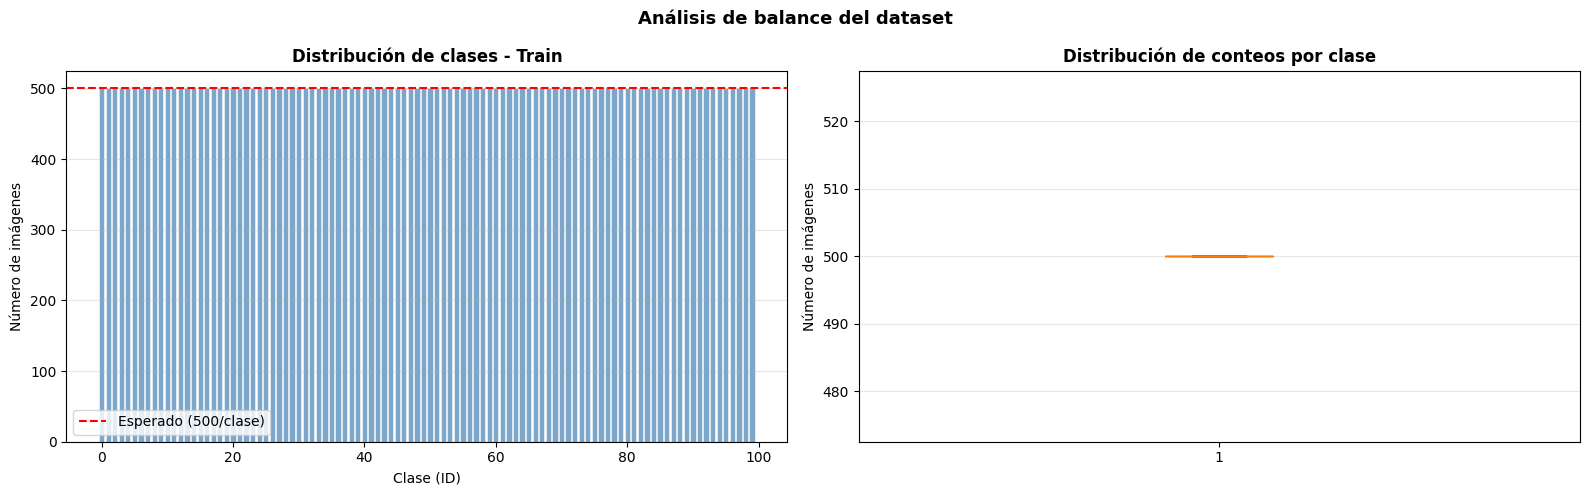


Estadísticas de distribución de clases:
   Min: 500 | Max: 500 | Media: 500.0 | Std: 0.00


In [ ]:
# Distribución de clases en train
unique_id, counts = np.unique(y_train_raw, return_counts=True)

# Histograma de distribución y Boxplot de conteos
plot_distribucion_clases(unique_id, counts, esperado_por_clase=500)

print(f"\nEstadísticas de distribución de clases:")
print(f"   Min: {counts.min()} | Max: {counts.max()} | Media: {counts.mean():.1f} | Std: {counts.std():.2f}")

**Conclusiones:**

*   El dataset está **perfectamente balanceado**: todas las clases tienen exactamente 500 imágenes en train, como confirma el boxplot (varianza cero, mediana = 500).
*   No es necesario aplicar técnicas de balanceo (oversampling, class weights) ya que ninguna clase está sobre o infrarrepresentada.
*   Con 100 clases, la probabilidad de clasificación aleatoria es del 1% (1/100), lo que establece la línea base mínima que cualquier modelo debe superar.

### 2.3 Visualización de muestras

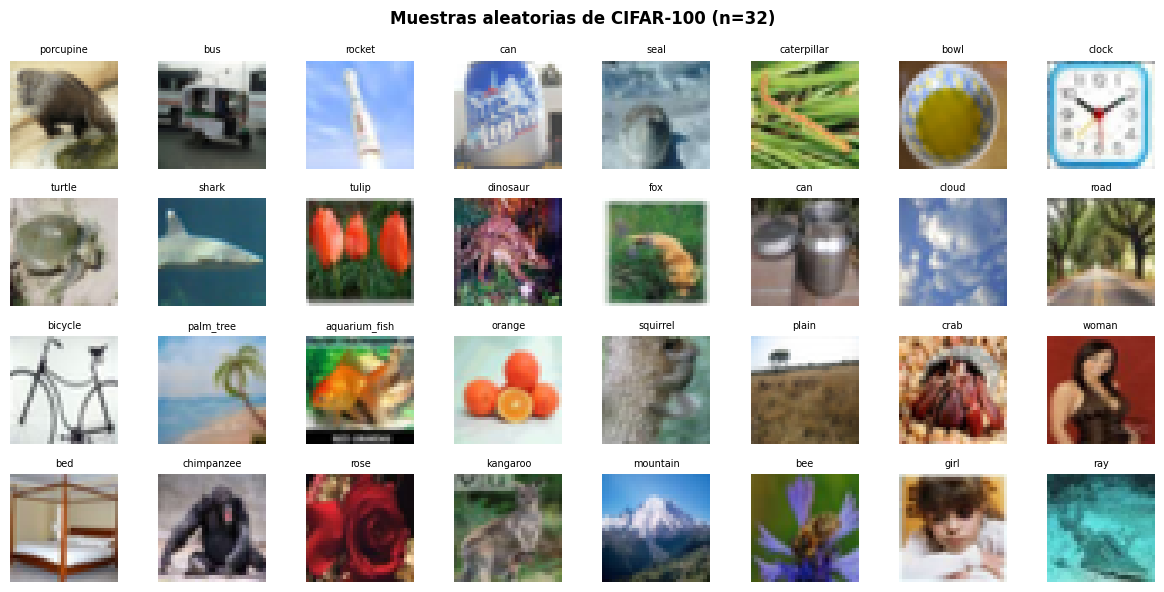

In [ ]:
plot_muestras(X_train_raw, y_train_raw)

---

## 3. PREPROCESAMIENTO

In [ ]:
# Normalizar pixeles a [0, 1]
X_train_norm = X_train_raw.astype('float32') / 255.0
X_test_norm = X_test_raw.astype('float32') / 255.0

# One-Hot Encoding para loss categorical_crossentropy
y_train_cat = to_categorical(y_train_raw, NUM_CLASSES)
y_test_cat = to_categorical(y_test_raw, NUM_CLASSES)

# Split train/val: 90% train, 10% validacion
# X_test_norm queda reservado exclusivamente para la evaluación final
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_norm,
    y_train_cat,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train_raw
)

print("Normalización de los datos:\n")
print(f"   X_train original: shape={X_train_norm.shape}, min={X_train_norm.min():.2f}, max={X_train_norm.max():.2f}")
print(f"   X_tr (train): {X_tr.shape} -> usado en entrenamiento")
print(f"   X_val (val): {X_val.shape} -> usado en validación")
print(f"   X_test (test): {X_test_norm.shape} -> reservado para evaluación final")

# Data Augmentation para Transfer Learning, genera versiones modificadas de
# las imágenes durante el entrenamiento en tiempo real
datagen = ImageDataGenerator(
    horizontal_flip=True,       # Voltea la imagen horizontalmente al azar
    rotation_range=15,      # Rota la imagen hasta +-15 grados al azar
    width_shift_range=0.1,      # Desplaza horizontalmente hasta el 10% del ancho
    height_shift_range=0.1,     # Desplaza verticalmente hasta el 10% del alto
    zoom_range=0.1          # Hace zoom de hasta el 10% al azar
)
datagen.fit(X_tr)

print("\nData Augmentation configurado (flip | rotation | shift | zoom)")

Normalización de los datos:

   X_train original: shape=(50000, 32, 32, 3), min=0.00, max=1.00
   X_tr (train): (45000, 32, 32, 3) -> usado en entrenamiento
   X_val (val): (5000, 32, 32, 3) -> usado en validación
   X_test (test): (10000, 32, 32, 3) -> reservado para evaluación final

Data Augmentation configurado (flip | rotation | shift | zoom)


---

## 4. ESTRATEGIA 1: *TRANSFER LEARNING + FINE TUNING*

Se comparan dos arquitecturas preentrenadas con ImageNet con filosofias de diseño opuestas:

| Arquitectura | Diseno | Caracteristica principal |
|---|---|---|
| **VGG16** | Clásica, lineal | Bloques de convolución 3x3 apilados |
| **MobileNetV2** | Convoluciones separables en profundidad | Arquitectura ligera y eficiente |

Para cada arquitectura:
1. **Feature Extraction**: La red preentrenada se usa tal cual, sin modificar sus pesos. Solo se entrena la parte nueva que añadimos encima (las capas Dense que clasifican las 100 clases de CIFAR-100).
2. **Fine Tuning**: Se "descongelan" las ultimas capas de la red preentrenada para que sus pesos tambien se ajusten a CIFAR-100. Se usa un learning rate muy bajo para no destruir lo que la red ya aprendio con ImageNet.

### 4.1 Arquitectura 1: VGG16

#### 4.1.1 Feature Extraction — VGG16

**VGG16**: arquitectura lineal de bloques Conv 3x3, clasica de referencia en vision. 5 bloques convolucionales -> base muy expresiva, con muchos parametros

[INFO] Construyendo VGG16 (Feature Extraction)...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
   Parámetros totales: 14,873,764
   Parámetros entrenables: 158,052  (1.1%)
   Parámetros congelados: 14,715,712

[INFO] Entrenando VGG16 - Feature Extraction...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 43ms/step - accuracy: 0.1454 - loss: 3.7911 - val_accuracy: 0.2654 - val_loss: 3.0530 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.2250 - loss: 3.2591 - val_accuracy: 0.3006 - val_loss: 2.9042 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.2449 - loss: 3.1253 - val_accuracy: 0.3156 - val_loss: 2.8245 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.2588 - loss: 3.0588 - val_accuracy: 0.3154 - val_loss: 2.7780 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.2677 - loss: 3.0160 - val_accuracy: 0.3190 - val_los

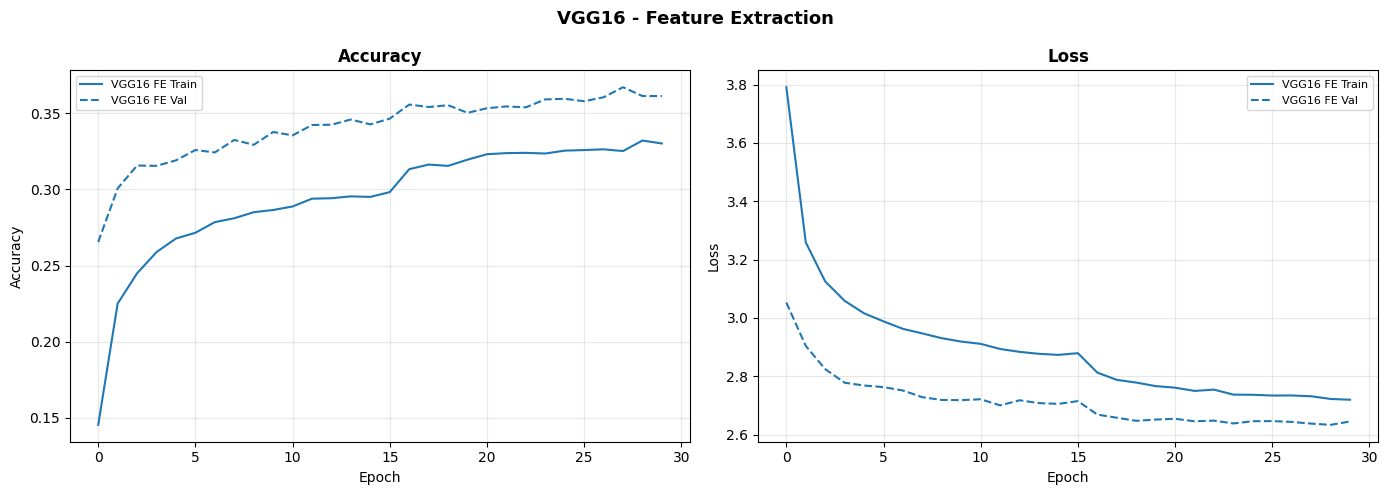


VGG16 FE — Test Accuracy: 0.3596 (35.96%) | Loss: 2.6062


In [ ]:
print("[INFO] Construyendo VGG16 (Feature Extraction)...")

# Carga VGG16 preentrenada con ImageNet, sin la cabeza clasificadora original
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_vgg.trainable = False      # Congela los pesos de VGG16: solo se entrena el clasificador nuevo

model_vgg = Sequential([
    base_vgg,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="VGG16_FE")

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cuenta parámetros entrenables (los que se actualizan en backpropagation)
trainable_fe = sum(np.prod(v.shape) for v in model_vgg.trainable_weights)
total = model_vgg.count_params()

print(f"   Parámetros totales: {total:,}")
print(f"   Parámetros entrenables: {trainable_fe:,}  ({100 * trainable_fe / total:.1f}%)")
print(f"   Parámetros congelados: {total - trainable_fe:,}")

print("\n[INFO] Entrenando VGG16 - Feature Extraction...")
t_init = time.time()

H_vgg_fe = model_vgg.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FE,
    callbacks=get_callbacks(),
    verbose=1
)

print(f"Tiempo: {time.time() - t_init:.0f}s")

plot_historia({'VGG16 FE': H_vgg_fe}, "VGG16 - Feature Extraction")

loss_vgg_fe, acc_vgg_fe = model_vgg.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nVGG16 FE — Test Accuracy: {acc_vgg_fe:.4f} ({acc_vgg_fe * 100:.2f}%) | Loss: {loss_vgg_fe:.4f}")

**Conclusiones:**

*   *VGG16* en Feature Extraction alcanza 35.96% de test accuracy, muy por encima de la linea base aleatoria del 1%, lo que confirma que las features de ImageNet son transferibles a CIFAR-100.

*   El patrón *val_accuracy* > *train_accuracy* es esperado: Dropout(0.5) reduce artificialmente el accuracy durante el entrenamiento pero se desactiva en validacion/test.

*   La convergencia es estable (sin overfitting), ya que la base congelada impide que el modelo memorice el conjunto de entrenamiento.

*   El principal limitante es el gap de resolución: *VGG16* fue diseñado para 224x224 px; con imágenes de 32x32 los feature maps pierden información espacial en los MaxPooling. El Fine Tuning deberia mejorar este resultado al adaptar las últimas capas al dominio CIFAR-100.

#### 4.1.2 Fine Tuning — VGG16

Solo descongelamos block5 (features de alto nivel: formas, objetos).

Block1-block4 permanecen congelados (bordes y texturas genericas de ImageNet, útiles para cualquier imagen).

[INFO] Capas de VGG16: 19
   Parámetros entrenables (FT): 7,237,476

[INFO] Entrenando VGG16 - Fine Tuning...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.3421 - loss: 2.6628 - val_accuracy: 0.3722 - val_loss: 2.5442 - learning_rate: 1.0000e-05
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3554 - loss: 2.5875 - val_accuracy: 0.3856 - val_loss: 2.5123 - learning_rate: 1.0000e-05
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.3631 - loss: 2.5403 - val_accuracy: 0.3892 - val_loss: 2.4697 - learning_rate: 1.0000e-05
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3752 - loss: 2.4865 - val_accuracy: 0.3906 - val_loss: 2.4553 - learning_rate: 1.0000e-05
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3815 - loss: 2.4528 - val_accuracy: 0.4024 - val_loss: 2.4276 - learning_rate: 1.0000e-05
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3853 - loss: 2.4286 - val_accura

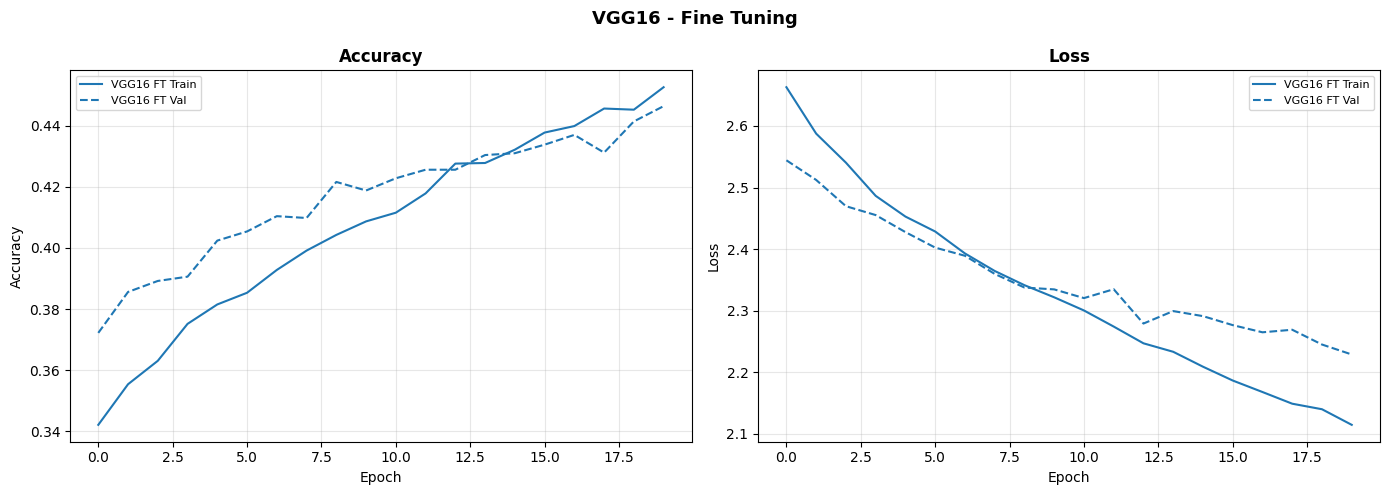


VGG16 FT — Test Accuracy: 0.4481 (44.81%) | Loss: 2.1975


In [ ]:
print(f"[INFO] Capas de VGG16: {len(base_vgg.layers)}")

# Descongela solo block5; el resto permanece congelado
base_vgg.trainable = True
for layer in base_vgg.layers:
    layer.trainable = 'block5' in layer.name

trainable_ft = sum(np.prod(v.shape) for v in model_vgg.trainable_weights)
print(f"   Parámetros entrenables (FT): {trainable_ft:,}")

# Learning Rate muy bajo: evitar destruir los pesos preentrenados
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n[INFO] Entrenando VGG16 - Fine Tuning...")
t_init = time.time()

H_vgg_ft = model_vgg.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FT,
    callbacks=get_callbacks(patience_es=6),
    verbose=1
)

print(f"Tiempo: {time.time() - t_init:.0f}s")

plot_historia({'VGG16 FT': H_vgg_ft}, "VGG16 - Fine Tuning")

loss_vgg_ft, acc_vgg_ft = model_vgg.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nVGG16 FT — Test Accuracy: {acc_vgg_ft:.4f} ({acc_vgg_ft * 100:.2f}%) | Loss: {loss_vgg_ft:.4f}")

**Conclusiones:**

*   Fine Tuning mejora +8.85 pp sobre Feature Extraction (35.96% -> 44.81%): adaptar las capas de alto nivel de *block5* al dominio CIFAR-100 con *LR=1e-5* tiene un impacto directo y claro.

*   El gap *train/val* en el mejor epoch (20) es mínimo: *train* 45.26% vs *val* 44.64%. El patrón *val* > *train* se mantiene igual que en Feature Extraction, confirmando que el Dropout del clasificador sigue siendo el efecto dominante incluso con *block5* descongelado.

*   Ambas curvas siguen ascendiendo al llegar a epoch 20 sin estabilizarse: el modelo aun tenia margen de mejora. Aumentar *EPOCHS_FT* podria extraer accuracy adicional.

*   El *LR=1e-5* produce un entrenamiento estable y gradual, protegiendo los pesos de los bloques congelados.

### 4.2 Arquitectura 2: MobileNetV2

#### 4.2.1 Feature Extraction — MobileNetV2

**MobileNetV2**: arquitectura ligera que separa el filtrado espacial de la combinación de canales. Resultado: muchos menos parámetros que *VGG16* con accuracy competitivo.

[INFO] Construyendo MobileNetV2 (Feature Extraction)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   Parámetros totales: 2,616,740
   Parámetros entrenables: 356,196 (13.6%)
   Parámetros congelados: 2,260,544

[INFO] Entrenando MobileNetV2 - Feature Extraction...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.0605 - loss: 4.3087 - val_accuracy: 0.0994 - val_loss: 4.0579 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.0885 - loss: 4.0745 - val_accuracy: 0.1140 - val_loss: 3.9924 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.0958 - loss: 4.0167 - val_accuracy: 0.1196 - val_loss: 3.9637 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.1042 - loss: 3.9874 - val_accuracy: 0.1194 - val_loss: 3.9577 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.1039 - loss: 3.9746 - val_accuracy: 0.1224 -

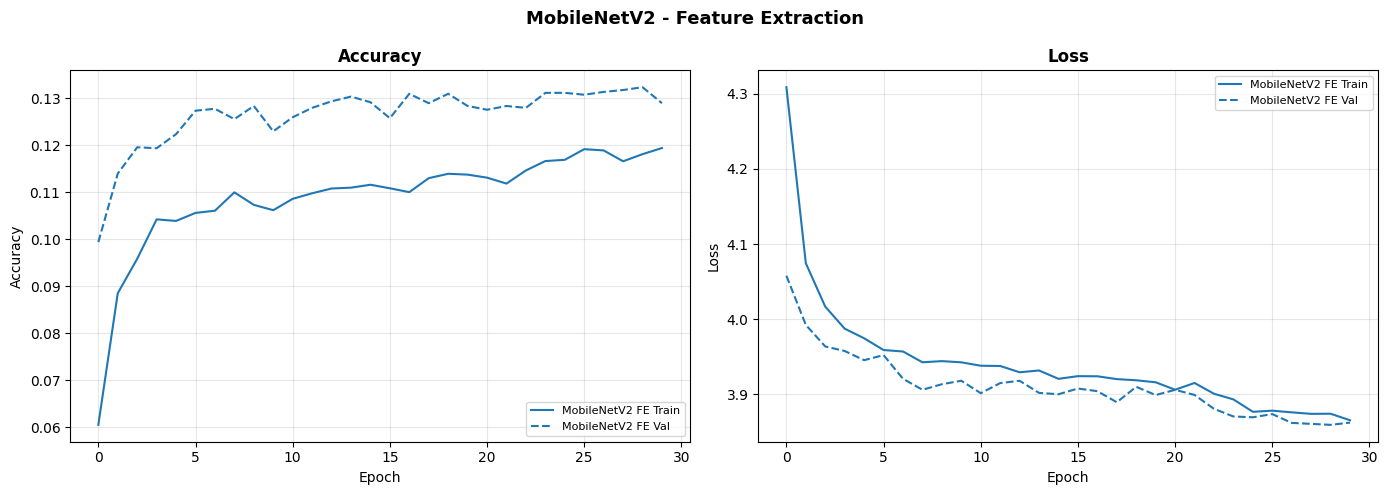


MobileNetV2 FE — Test Accuracy: 0.1398 (13.98%) | Loss: 3.8558


In [ ]:
print("[INFO] Construyendo MobileNetV2 (Feature Extraction)...")

base_mob = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_mob.trainable = False      # Congela toda la base

model_mob = Sequential([
    base_mob,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="MobileNetV2_FE")

model_mob.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Cuenta parámetros entrenables (los que se actualizan en backpropagation)
trainable_fe = sum(np.prod(v.shape) for v in model_mob.trainable_weights)
total = model_mob.count_params()

print(f"   Parámetros totales: {total:,}")
print(f"   Parámetros entrenables: {trainable_fe:,} ({100 * trainable_fe / total:.1f}%)")
print(f"   Parámetros congelados: {total - trainable_fe:,}")

print("\n[INFO] Entrenando MobileNetV2 - Feature Extraction...")
t_init = time.time()

H_mob_fe = model_mob.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FE,
    callbacks=get_callbacks(),
    verbose=1
)

print(f"Tiempo: {time.time() - t_init:.0f}s")

plot_historia({'MobileNetV2 FE': H_mob_fe}, "MobileNetV2 - Feature Extraction")

loss_mob_fe, acc_mob_fe = model_mob.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nMobileNetV2 FE — Test Accuracy: {acc_mob_fe:.4f} ({acc_mob_fe * 100:.2f}%) | Loss: {loss_mob_fe:.4f}")

**Conclusiones:**

*   *MobileNetV2* en Feature Extraction obtiene 13.98%, muy por debajo de *VGG16 FE* (35.96%). Esto se explica por su mayor sensibilidad a la resolución de entrada: su *stride=2* inicial colapsa los feature maps de 32x32 muy rápidamente, degradando la calidad de las representaciones con pesos congelados.

*   El patron *val* > *train* se mantiene igual que en *VGG16 FE* por el efecto del Dropout.

*   El Fine Tuning es especialmente importante para *MobileNetV2* en este dataset: sin adaptar sus pesos al dominio 32x32, las features de ImageNet no son suficientemente útiles.

#### 4.2.2 Fine Tuning — MobileNetV2

Descongelamos las últimas 20 capas (las que capturan features específicas de alto nivel). Las primeras capas permanecen congeladas (features genéricas reutilizables de ImageNet).

[INFO] Capas de MobileNetV2: 154
   Parámetros entrenables (FT): 1,562,276

[INFO] Entrenando MobileNetV2 - Fine Tuning...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 52ms/step - accuracy: 0.0577 - loss: 4.7072 - val_accuracy: 0.0132 - val_loss: 4.8348 - learning_rate: 1.0000e-05
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.0849 - loss: 4.1543 - val_accuracy: 0.0318 - val_loss: 4.5335 - learning_rate: 1.0000e-05
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.1026 - loss: 3.9718 - val_accuracy: 0.0736 - val_loss: 4.2252 - learning_rate: 1.0000e-05
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.1188 - loss: 3.8508 - val_accuracy: 0.1152 - val_loss: 3.9331 - learning_rate: 1.0000e-05
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.1349 - loss: 3.7544 - val_accuracy: 0.1530 - val_loss: 3.6706 - learning_rate: 1.0000e-05
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.1474 - loss: 3.6726

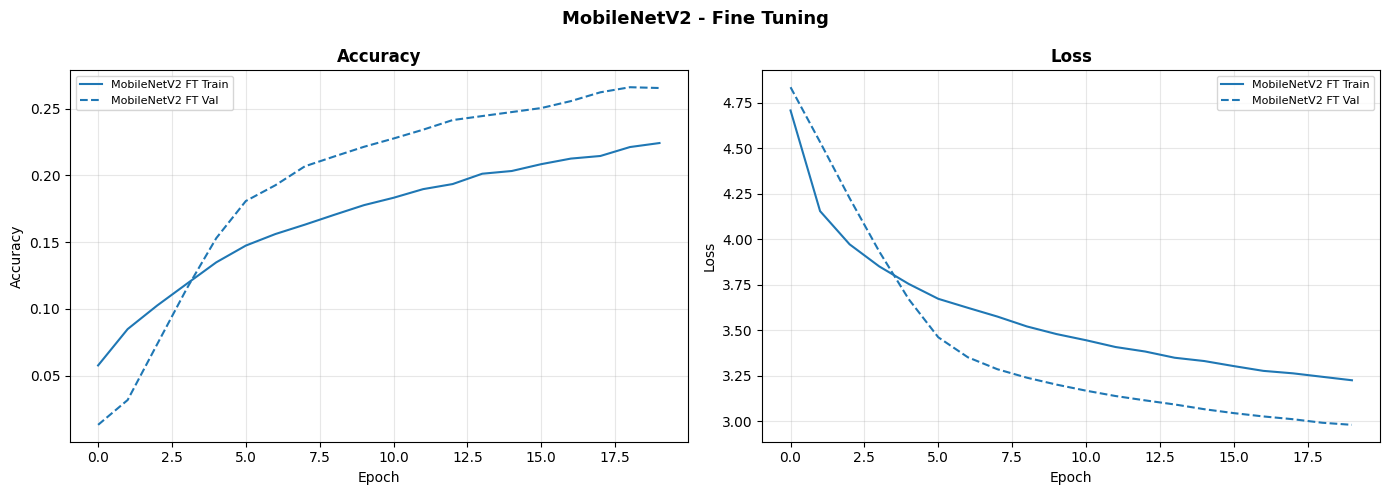


MobileNetV2 FT — Test Accuracy: 0.2731 (27.31%) | Loss: 2.9608


In [ ]:
print(f"[INFO] Capas de MobileNetV2: {len(base_mob.layers)}")

# Descongela las últimas 20 capas; el resto permanece congelado
base_mob.trainable = True
for layer in base_mob.layers[:-20]:
    layer.trainable = False

for layer in base_mob.layers[-20:]:
    layer.trainable = True

trainable_ft = sum(np.prod(v.shape) for v in model_mob.trainable_weights)
print(f"   Parámetros entrenables (FT): {trainable_ft:,}")

# Learning Rate muy bajo: evitar destruir los pesos preentrenados
model_mob.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n[INFO] Entrenando MobileNetV2 - Fine Tuning...")
t_init = time.time()

H_mob_ft = model_mob.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FT,
    callbacks=get_callbacks(patience_es=6),
    verbose=1
)

print(f"Tiempo: {time.time() - t_init:.0f}s")

plot_historia({'MobileNetV2 FT': H_mob_ft}, "MobileNetV2 - Fine Tuning")

loss_mob_ft, acc_mob_ft = model_mob.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nMobileNetV2 FT — Test Accuracy: {acc_mob_ft:.4f} ({acc_mob_ft * 100:.2f}%) | Loss: {loss_mob_ft:.4f}")

**Conclusiones:**

*   El Fine Tuning mejora +13.33 pp sobre FE (13.98% -> 27.31%): descongelar las últimas 20 capas permite que la red adapte sus representaciones de alto nivel al dominio CIFAR-100 con imágenes de 32x32.

*   Una vez estabilizado el entrenamiento (a partir del epoch 3), el patrón *val* > *train* se mantiene de forma consistente (best epoch 19: *train* 22.12% vs *val* 26.60%), confirmando que el Dropout del clasificador es el efecto dominante.

*   Ambas curvas siguen ascendiendo al llegar a epoch 20 sin estabilizarse: el modelo aún estaba aprendiendo al final del entrenamiento. Aumentar *EPOCHS_FT* produciría mejora adicional.

*   A pesar de la mejora, el resultado (27.31%) sigue por debajo de *VGG16 FT* (44.81%), lo que indica que las 20 capas descongeladas no son suficientes para compensar el impacto del *stride=2* en las capas iniciales que permanecen congeladas.

### 4.3 Comparativa Estrategia 1

TABLA COMPARATIVA — TRANSFER LEARNING
Modelo               Test Acc  Test Loss
-----------------------------------------------------------------
VGG16 FE               35.96%     2.6062
VGG16 FT               44.81%     2.1975
MobileNetV2 FE         13.98%     3.8558
MobileNetV2 FT         27.31%     2.9608
-----------------------------------------------------------------

Mejor modelo: VGG16 FT (44.81%)


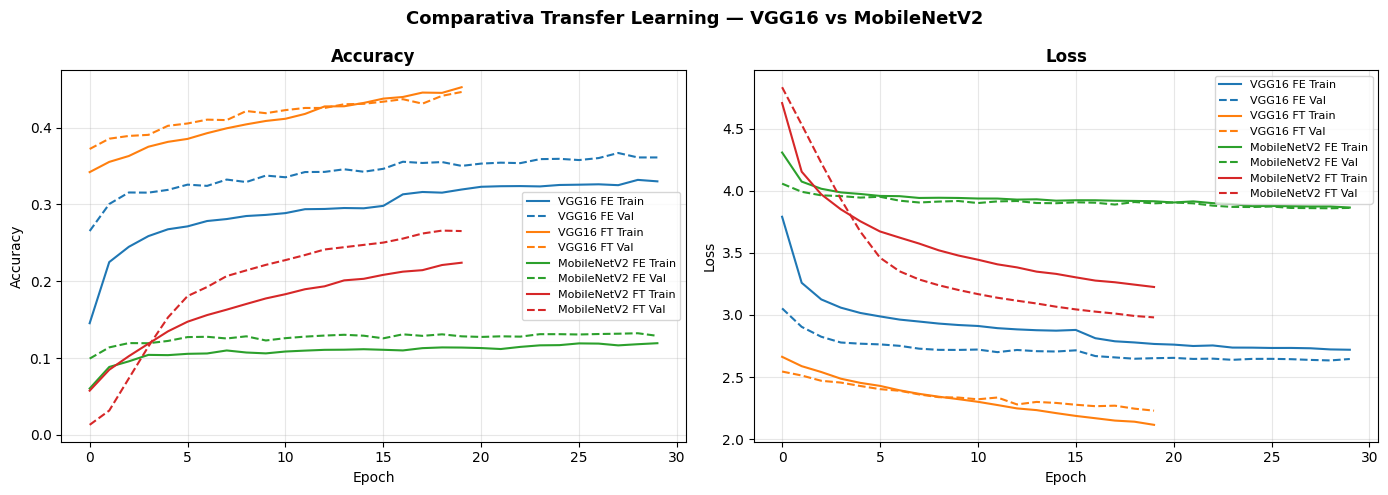

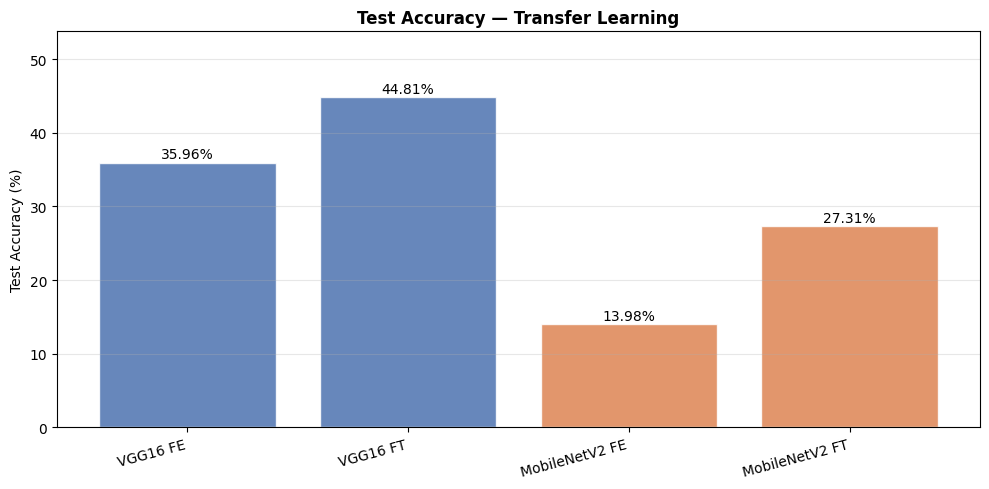

In [ ]:
resultados_tl = {
    'VGG16 FE': (acc_vgg_fe, loss_vgg_fe),
    'VGG16 FT': (acc_vgg_ft, loss_vgg_ft),
    'MobileNetV2 FE': (acc_mob_fe, loss_mob_fe),
    'MobileNetV2 FT': (acc_mob_ft, loss_mob_ft),
}

plot_comparativa(
    resultados_tl,
    {
        'VGG16 FE': H_vgg_fe,
        'VGG16 FT': H_vgg_ft,
        'MobileNetV2 FE': H_mob_fe,
        'MobileNetV2 FT': H_mob_ft
    },
    titulo_tabla="TABLA COMPARATIVA — TRANSFER LEARNING",
    titulo_historia="Comparativa Transfer Learning — VGG16 vs MobileNetV2",
    titulo_barras="Test Accuracy — Transfer Learning",
    colores=[
        '#4C72B0',
        '#4C72B0',
        '#DD8452',
        '#DD8452'
    ]
)

**Conclusiones:**

*   El *Fine Tuning* mejora sobre *Feature Extraction* en ambas arquitecturas:

    *VGG16* +8.85 pp (35.96% -> 44.81%) y *MobileNetV2* +13.33 pp (13.98% -> 27.31%).
    Adaptar las capas de alto nivel al dominio CIFAR-100 siempre aporta, independientemente de la arquitectura.

*   *VGG16* supera a *MobileNetV2* en ambas fases, resultado contraintuitivo respecto a la expectativa general. La causa es la resolución de entrada: con imágenes de 32x32, el *stride=2* inicial de *MobileNetV2* colapsa los feature maps rápidamente, haciendo sus representaciones menos útiles que las de *VGG16*, cuya reducción espacial es mas gradual.

*   *MobileNetV2 FT* (27.31%) queda incluso por debajo de *VGG16 FE* (35.96%):

    *VGG16* con la base completamente congelada supera a *MobileNetV2* con 20 capas descongeladas, lo que evidencia el impacto de la incompatibilidad de resolución en *MobileNetV2*.

*   Ambos modelos tenían margen de mejora al finalizar el entrenamiento: *VGG16 FT* y *MobileNetV2 FT* seguían ascendiendo en epoch 20 sin estabilizarse. Aumentar *EPOCHS_FT* produciría mejoras adicionales en ambos casos.

*   Todos los modelos superan ampliamente la línea base del 1% (clasificación aleatoria), confirmando que el conocimiento de ImageNet es transferible a CIFAR-100 incluso con el desajuste de resolución.

---

## 5. ESTRATEGIA 2: RED NEURONAL DESDE CERO (FROM SCRATCH)

Diseñamos y optimizamos una CNN propia sin pesos preentrenados, aplicando las técnicas de optimización de forma **progresiva e incremental** para justificar empíricamente el impacto de cada una.

| Modelo | Tecnicas |
|--------|---------|
| CNN Base | Ninguna — línea base |
| CNN + L2 | + Weight Regularization L2 (estandar en redes convolucionales) |
| CNN + L2 + Dropout | + Dropout |
| CNN Optimizada | + Batch Normalization + Data Augmentation |

<br>

### 5.1 Modelo base — sin regularización (línea base)

**Objetivo:** establecer la línea base y visualizar el *overfitting* antes de optimizar.

Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 643,492 (2.45 MB)

 Trainable params: 643,492 (2.45 MB)

 Non-trainable params: 0 (0.00 B)


[INFO] Entrenando CNN Base...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1216 - loss: 3.8113 - val_accuracy: 0.1846 - val_loss: 3.4048
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2602 - loss: 3.0172 - val_accuracy: 0.2800 - val_loss: 2.9034
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3408 - loss: 2.6135 - val_accuracy: 0.3290 - val_loss: 2.7052
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3983 - loss: 2.3368 - val_accuracy: 0.3540 - val_loss: 2.5693
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4441 - loss: 2.1227 - val_accuracy: 0.3694 - val_loss: 2.5325
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4877 - loss: 1.9441 - val_accuracy: 0.3646 - val_loss: 2.5576
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5237 - loss: 1.7895 - val_accuracy: 0.3778 - val_loss: 2.5731
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5542 -

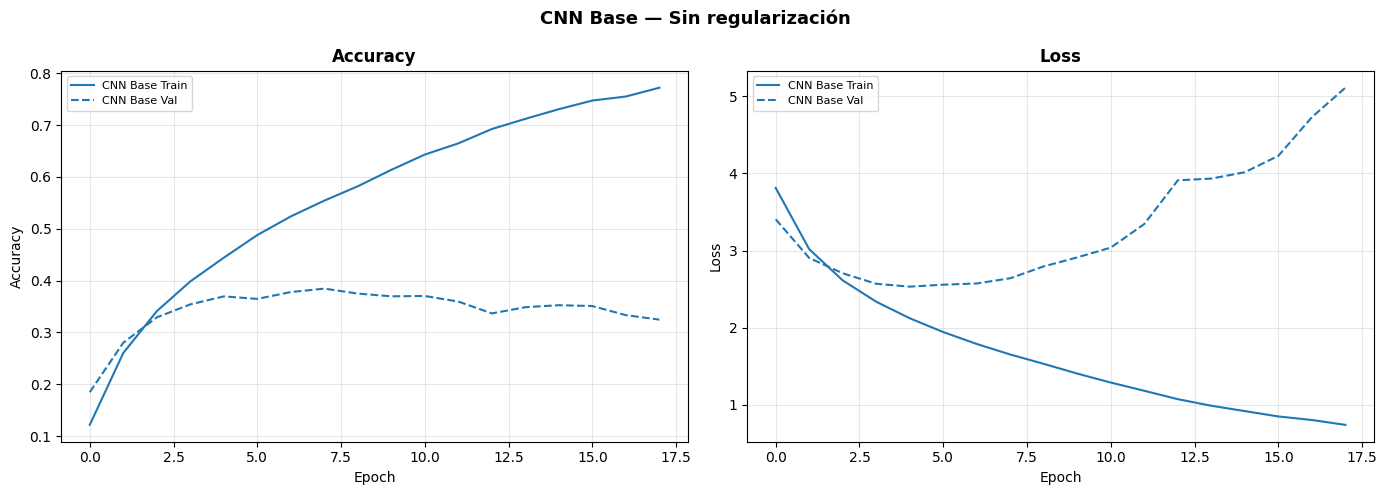


CNN Base — Test Accuracy: 0.3857 (38.57%) | Loss: 2.6539


In [ ]:
# Modelo base: mínima arquitectura sin ninguna técnica de regularización
model_base = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="CNN_Base")

model_base.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_base.summary()

print("\n[INFO] Entrenando CNN Base...")
H_base = model_base.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_SCR,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)],
    verbose=1
)

plot_historia({'CNN Base': H_base}, "CNN Base — Sin regularización")

loss_base, acc_base = model_base.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nCNN Base — Test Accuracy: {acc_base:.4f} ({acc_base * 100:.2f}%) | Loss: {loss_base:.4f}")

**Overfitting claro y severo**.

*Accuracy:*

*   *Train* sigue subiendo hasta ~75% al epoch 15.
*   *Val* se estanca alrededor del 33-35% desde el epoch 3 y luego baja ligeramente.
*   Gap final: ~40 puntos porcentuales entre *train* y *val*.

*Loss:*

*   *Train* baja continuamente hasta ~0.9.
*   *Val* baja hasta el epoch 2-3 y luego sube sin parar hasta ~5.1.
*   Las dos curvas divergen completamente: es muy común en **overfitting**.

*Test Accuracy: 38.57%*

*   Supera la línea base aleatoria del 1%, por lo que el modelo aprende algo.
*   Pero el gap con el train (~75%) confirma que memoriza en lugar de generalizar.

**Conclusiones:**

El modelo base sin regularización aprende muy bien los datos de entrenamiento pero falla en generalizar. Es exactamente el comportamiento esperado que justifica introducir las técnicas de optimización en los pasos siguientes.

*Reducción espacial progresiva:*

*   La imagen entra como 32x32 y se reduce a 4x4 tras los tres MaxPooling. Cada pooling divide el alto y ancho a la mitad.

*Aumento de filtros:*

*   32 -> 64 -> 128 filtros por bloque. Patrón estándar: a medida que la imagen se reduce espacialmente, se aumentan los filtros para compensar y capturar más patrones.

*Cuello de botella en Dense:*

*   El 81% de los parámetros totales (524,544 de 643,492) están en la primera capa Dense. Esto es un problema típico cuando se usa Flatten: el vector de 2048 valores conectado a 256 neuronas genera muchos parámetros concentrados en un solo punto. En el modelo optimizado esto se resuelve con GlobalAveragePooling2D.

*MaxPooling no tiene parámetros:*

*   Los 0 params en todas las capas MaxPooling confirman que no aprende nada, solo reduce el tamaño seleccionando el valor máximo de cada ventana.

### 5.2 Modelo con *Weight Regularization (L2)*

L2 añade una penalización a la función de pérdida proporcional al cuadrado de los pesos: cuanto más grandes son los pesos, mayor es la penalización, lo que obliga a la red a mantenerlos pequeños y distribuir la información entre más neuronas.

[INFO] Entrenando CNN + L2...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1282 - loss: 3.8178 - val_accuracy: 0.1744 - val_loss: 3.5775
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2602 - loss: 3.0623 - val_accuracy: 0.2612 - val_loss: 3.0786
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3338 - loss: 2.7187 - val_accuracy: 0.3076 - val_loss: 2.8590
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3903 - loss: 2.4767 - val_accuracy: 0.3366 - val_loss: 2.7685
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4343 - loss: 2.2832 - val_accuracy: 0.3500 - val_loss: 2.7378
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4747 - loss: 2.1213 - val_accuracy: 0.3594 - val_loss: 2.7610
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5146 - loss: 1.9793 - val_accuracy: 0.3650 - val_loss: 2.8082
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5406 - 

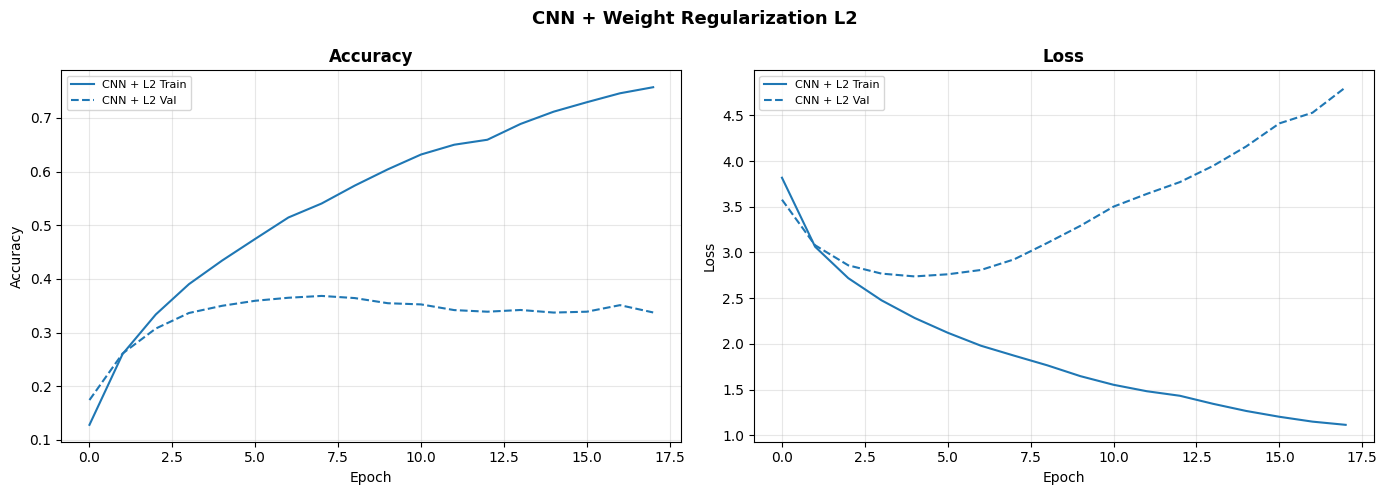


CNN + L2 — Test Accuracy: 0.3736 (37.36%) | Loss: 2.9457


In [ ]:
model_l2 = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3), kernel_regularizer=regularizers.l2(1e-4)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dense(NUM_CLASSES, activation='softmax')
], name="CNN_L2")

model_l2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("[INFO] Entrenando CNN + L2...")
H_l2 = model_l2.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_SCR,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)],
    verbose=1
)

plot_historia({'CNN + L2': H_l2}, "CNN + Weight Regularization L2")

loss_l2, acc_l2 = model_l2.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nCNN + L2 — Test Accuracy: {acc_l2:.4f} ({acc_l2 * 100:.2f}%) | Loss: {loss_l2:.4f}")

**Conclusiones:**

*Accuracy:*

*   *Train* sigue subiendo hasta ~75%, igual que el modelo base.
*   *Val* se mantiene en ~34-35%, prácticamente idéntico al modelo base (~33%).
*   El gap *train/val* sigue siendo de ~40 puntos: L2 solo no ha reducido el **overfitting** de forma visible.

*Loss:*

*   El comportamiento es casi idéntico al modelo base: *train* baja continuamente, *val* sube a partir del epoch 3-4 hasta ~4.7.
*   La divergencia entre ambas curvas es igual de severa que antes.

*Test Accuracy: 37.36%* vs *38.57% del modelo base*:

*   Empeoró ligeramente respecto al modelo base.

L2 con *lambda=1e-4* no solo no mejora el *test accuracy* sino que lo reduce ligeramente respecto al modelo base. La regularización penaliza la capacidad del modelo sin reducir el **overfitting** de forma visible a este nivel de lambda. L2 solo es insuficiente para un problema de 100 clases con este grado de sobreajuste.

El siguiente paso, Dropout, debería producir una mejora más visible al desactivar neuronas directamente durante el entrenamiento.

### 5.3 Modelo con Dropout

Dropout desactiva neuronas aleatoriamente durante el entrenamiento, lo que impide que la red dependa de neuronas específicas (mejor generalización).

Tasa 0.25 en capas convolucionales, 0.5 en capas densas (convención estandar)

[INFO] Entrenando CNN + L2 + Dropout...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.0599 - loss: 4.2129 - val_accuracy: 0.1238 - val_loss: 3.8504
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1473 - loss: 3.6596 - val_accuracy: 0.1940 - val_loss: 3.4634
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1916 - loss: 3.4183 - val_accuracy: 0.2376 - val_loss: 3.2169
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2226 - loss: 3.2646 - val_accuracy: 0.2724 - val_loss: 3.0574
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2502 - loss: 3.1447 - val_accuracy: 0.2984 - val_loss: 2.9257
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2655 - loss: 3.0638 - val_accuracy: 0.3172 - val_loss: 2.8650
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2844 - loss: 2.9879 - val_accuracy: 0.3282 - val_loss: 2.8031
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy

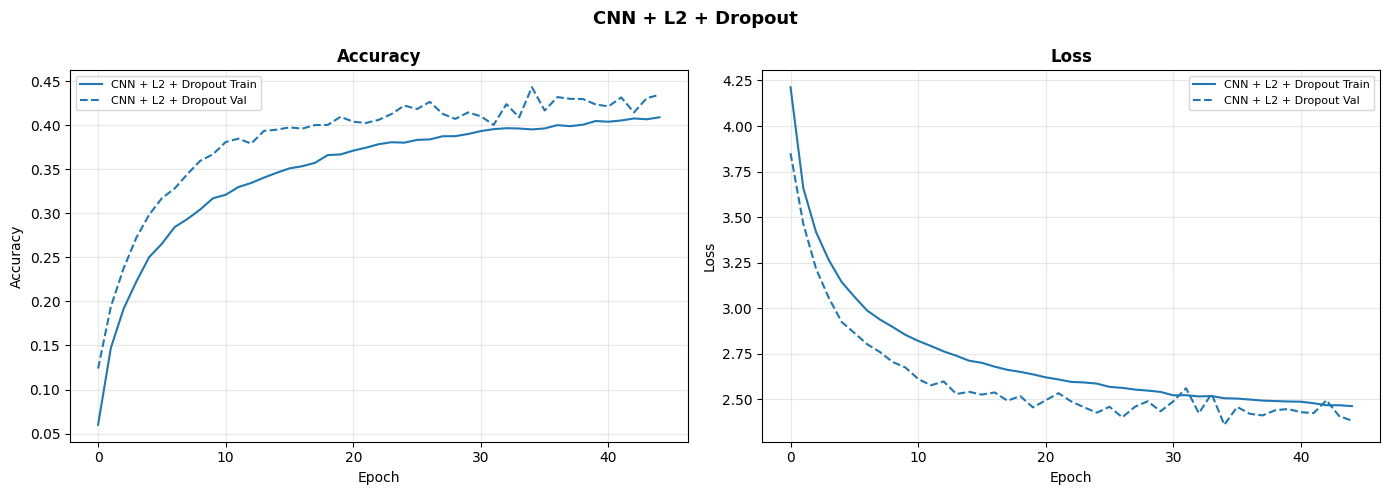


CNN + L2 + Dropout — Test Accuracy: 0.4483 (44.83%) | Loss: 2.3416


In [ ]:
model_drop = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3), kernel_regularizer=regularizers.l2(1e-4)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="CNN_L2_Dropout")

model_drop.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("[INFO] Entrenando CNN + L2 + Dropout...")
H_drop = model_drop.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_SCR,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)],
    verbose=1
)

plot_historia({'CNN + L2 + Dropout': H_drop}, "CNN + L2 + Dropout")

loss_drop, acc_drop = model_drop.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nCNN + L2 + Dropout — Test Accuracy: {acc_drop:.4f} ({acc_drop * 100:.2f}%) | Loss: {loss_drop:.4f}")

**Conclusiones:**

*Accuracy:*

*   La curva *val* supera a la curva *train* durante casi todo el entrenamiento (comportamiento opuesto a los modelos anteriores).
*   *Train* llega a ~40%, *val* a ~43%.
*   El gap ha desaparecido completamente: ya no hay overfitting.

*Loss:*
*   Ambas curvas bajan juntas y convergen hacia ~2.5.
*   *Val loss* sigue bajando hasta el final sin divergir, al contrario que CNN Base y CNN+L2.

*Test Accuracy: 44.83%* vs *37.36% (L2)* vs *38.57% (Base)*:

*   Mejora de +7.47 puntos porcentuales sobre L2.
*   Mejora de +6.26 puntos sobre el modelo base.
*   Es la mayor mejora individual vista hasta ahora.

Por qué *val* > *train*:

**Durante el entrenamiento**, *Dropout* desactiva neuronas al azar, haciendo la tarea más difícil para el modelo. Durante la evaluación y predicción, todas las neuronas están activas, por lo que el modelo rinde con su capacidad completa. Por eso es normal que *val accuracy* supere a *train accuracy* cuando se usan tasas de *Dropout* altas.

Dropout es la técnica con mayor impacto individual hasta ahora. Ha eliminado el **overfitting** y mejorado el accuracy en *test* en más de 7 puntos. Confirma exactamente lo visto en la clase: *Dropout* tiene un gran impacto sobre el gap *train/val*.

### 5.4 Modelo optimizado — Batch Normalization + Data Augmentation

Modelo final con todas las técnicas:

*   *L2*: penaliza pesos grandes.

*   *Dropout*: desactiva neuronas al azar.

*   *BatchNormalization*: normaliza activaciones entre capas (entrenamiento mas estable).

*   GlobalAveragePooling2D: En lugar de convertir todo el volumen en un vector largo como hace *Flatten*, calcula el promedio de cada mapa de features y devuelve un unico valor por filtro. Esto reduce drasticamente el numero de parametros del
  clasificador y con ello el riesgo de overfitting.

*   Data Augmentation: En cada epoch aplica transformaciones aleatorias a las imagenes de entrenamiento (volteos, rotaciones, zoom...), de forma que el modelo nunca ve exactamente la misma imagen dos veces. Esto simula tener mas datos de entrenamiento sin necesidad de recopilarlos realmente.

Model: "CNN_Optimizada"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 256)      │             

 Total params: 1,333,924 (5.09 MB)

 Trainable params: 1,331,108 (5.08 MB)

 Non-trainable params: 2,816 (11.00 KB)


[INFO] Entrenando CNN Optimizada...
Epoch 1/80
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 49ms/step - accuracy: 0.0829 - loss: 4.1930 - val_accuracy: 0.0610 - val_loss: 4.6813 - learning_rate: 0.0010
Epoch 2/80
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.1715 - loss: 3.5314 - val_accuracy: 0.1862 - val_loss: 3.4582 - learning_rate: 0.0010
Epoch 3/80
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.2445 - loss: 3.1476 - val_accuracy: 0.2308 - val_loss: 3.3901 - learning_rate: 0.0010
Epoch 4/80
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.2979 - loss: 2.8975 - val_accuracy: 0.3162 - val_loss: 2.8721 - learning_rate: 0.0010
Epoch 5/80
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3392 - loss: 2.7364 - val_accuracy: 0.2966 - val_loss: 3.0539 - learning_rate: 0.0010
Epoch 6/80
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.3707 - loss: 2.6175 - val_accuracy: 0.3322 - val_loss: 2.8308 - learning_rate: 0.0010
Epoch 7/80
704/704 ━━━━━━━━━━━━━━━━━━━━

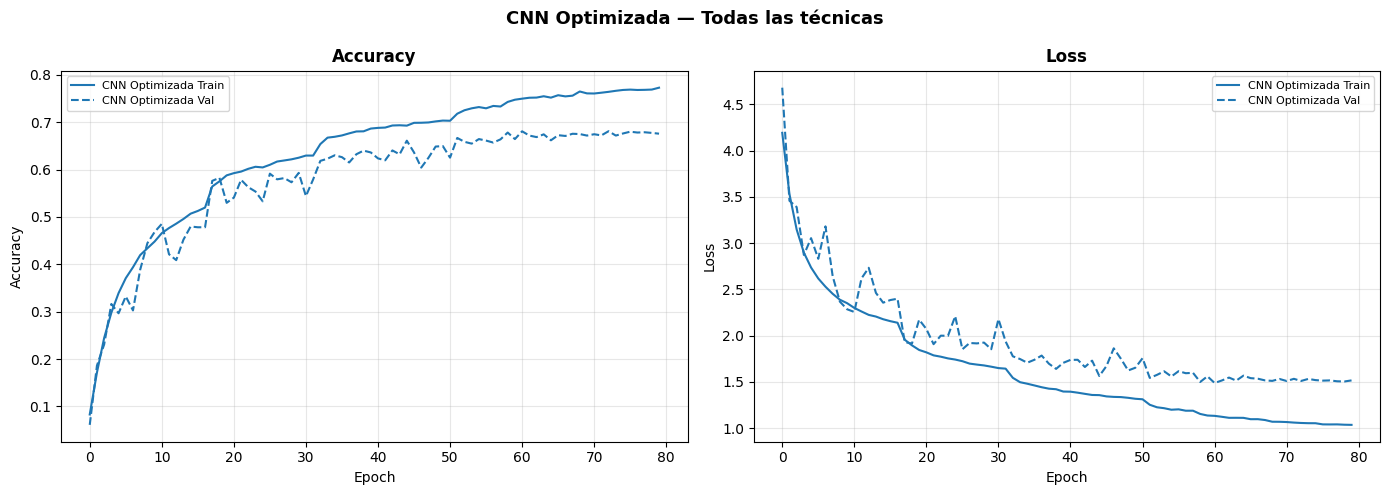


CNN Optimizada — Test Accuracy: 0.6736 (67.36%) | Loss: 1.5281


In [ ]:
model_opt = Sequential([
    # Bloque 1: 64 filtros
    Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3), kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque 2: 128 filtros
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Bloque 3: 256 filtros
    Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Clasificador
    GlobalAveragePooling2D(),       # Sustituye Flatten -> menos parámetros
    Dense(512, kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
], name="CNN_Optimizada")

model_opt.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_opt.summary()

print("\n[INFO] Entrenando CNN Optimizada...")
t_init = time.time()

H_opt = model_opt.fit(
    datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE),     # Data Augmentation: ampliar el train set con transformaciones realistas
    validation_data=(X_val, y_val),
    epochs=EPOCHS_OPT,
    callbacks=get_callbacks(patience_es=12, patience_lr=6),
    verbose=1
)

print(f"Tiempo: {time.time() - t_init:.0f}s")

plot_historia({'CNN Optimizada': H_opt}, "CNN Optimizada — Todas las técnicas")

loss_opt, acc_opt = model_opt.evaluate(X_test_norm, y_test_cat, verbose=0)
print(f"\nCNN Optimizada — Test Accuracy: {acc_opt:.4f} ({acc_opt * 100:.2f}%) | Loss: {loss_opt:.4f}")

**Conclusiones:**

*   La *CNN Optimizada* alcanza 67.36% de *test accuracy* con solo 1.33M parametros (5.09 MB), el mejor resultado de la Estrategia 2 y una mejora de +22.53 pp sobre el modelo anterior (*CNN + L2 + Dropout*).

*   El **overfitting** se redujo drásticamente respecto al modelo base: el gap *train*/*val* en el mejor epoch es de 8.31 pp (76.41% vs 68.10%), frente a los ~40 pp del modelo sin regularización.

*   Las oscilaciones en *val_loss* durante los primeros epochs son esperadas con Data Augmentation: cada epoch presenta variantes distintas de las imágenes, haciendo el entrenamiento más ruidoso pero mejorando la generalización.

*   *GlobalAveragePooling2D* permite mantener el modelo muy ligero (1.33M params) a pesar de usar 256 filtros en el último bloque convolucional.

### 5.5 Comparativa Estrategia 2

TABLA COMPARATIVA — FROM SCRATCH (evolución por técnica)
Modelo                             Test Acc  Test Loss
-----------------------------------------------------------------
CNN Base                             38.57%     2.6539
CNN + L2                             37.36%     2.9457
CNN + L2 + Dropout                   44.83%     2.3416
CNN + L2 + Dropout + BN + DA         67.36%     1.5281
-----------------------------------------------------------------

Mejor modelo: CNN + L2 + Dropout + BN + DA (67.36%)


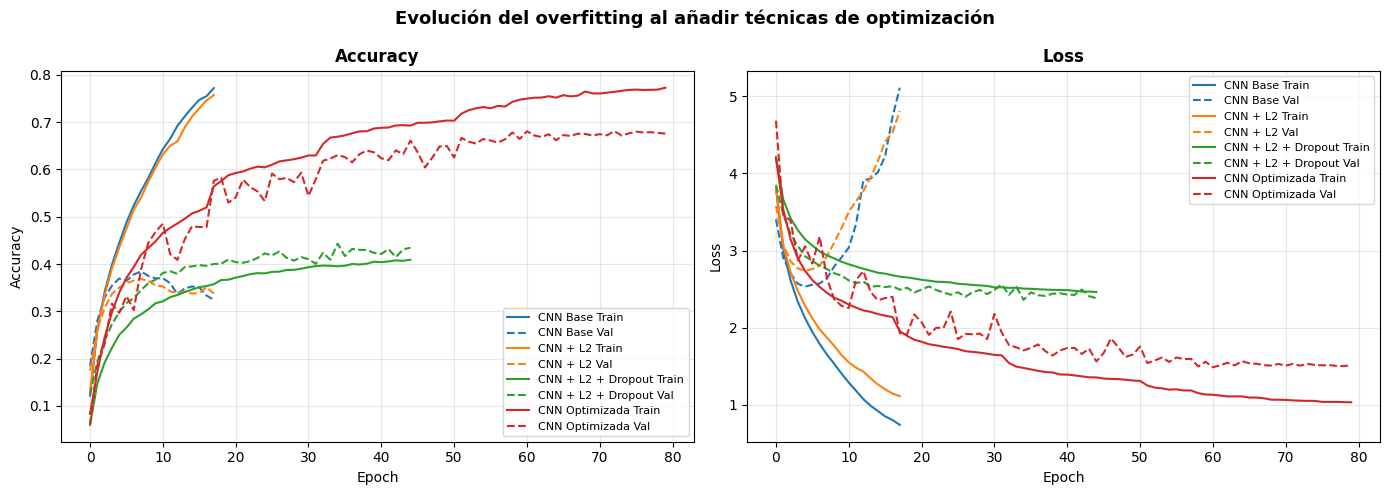

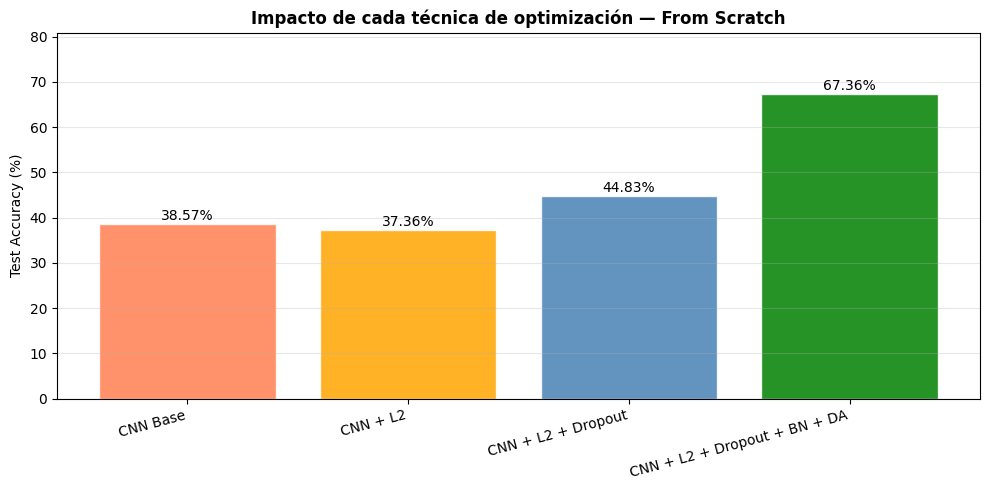

In [ ]:
modelos_scratch = {
    'CNN Base': (acc_base, loss_base),
    'CNN + L2': (acc_l2, loss_l2),
    'CNN + L2 + Dropout': (acc_drop, loss_drop),
    'CNN + L2 + Dropout + BN + DA': (acc_opt, loss_opt),
}

plot_comparativa(
    modelos_scratch,
    {
        'CNN Base': H_base,
        'CNN + L2': H_l2,
        'CNN + L2 + Dropout': H_drop,
        'CNN Optimizada': H_opt
    },
    titulo_tabla="TABLA COMPARATIVA — FROM SCRATCH (evolución por técnica)",
    titulo_historia="Evolución del overfitting al añadir técnicas de optimización",
    titulo_barras="Impacto de cada técnica de optimización — From Scratch",
    colores=[
        'coral',
        'orange',
        'steelblue',
        'green'
    ]
)

**Conclusiones:**

*   *L2* sola no mejora el modelo base (37.36% vs 38.57%): penaliza la capacidad del modelo sin reducir el **overfitting** de forma visible. Las curvas *train*/*val* de *CNN Base* y *CNN + L2* son prácticamente idénticas en las gráficas, confirmando que *L2* es insuficiente por sí sola para 100 clases con este nivel de sobreajuste.

*   *Dropout* produce el primer salto real (37.36% -> 44.83%, +7.47 pp): es la técnica con mayor impacto individual sobre el **overfitting**. Las curvas *val* de *CNN + L2 + Dropout* se separan visiblemente hacia arriba respecto a los dos modelos anteriores.

*   *BN + Data Augmentation* produce el mayor salto (44.83% -> 67.36%, +22.53 pp): la combinación de todas las técnicas multiplica el rendimiento. La *CNN Optimizada* es la única que muestra curvas *train* y *val* con una trayectoria ascendente sostenida hasta epoch 80, frente al plateau temprano de los modelos anteriores.

*   El impacto de cada técnica es acumulativo pero desigual: *L2* aporta poco de forma aislada, *Dropout* aporta de forma moderada, y *BN + DataAug* es donde se concentra la mayor ganancia. Esto se ve claramente en el gráfico de barras: el salto de las dos primeras barras es mínimo, el de la tercera es moderado, y el de la cuarta es dominante.

*   La *CNN Optimizada* es el único modelo que mantiene una tendencia ascendente sostenida hasta epoch 80. *CNN Base* y *CNN + L2* se estabilizan hacia epoch 15-20, y *CNN + L2 + Dropout* hacia epoch 30-35. *Data Augmentation* evita la estabilización prematura generando variantes distintas de las imágenes en cada epoch, permitiendo que el modelo siga aprendiendo durante mas tiempo.

---

## 6. COMPARACIÓN FINAL — ESTRATEGIA 1 vs ESTRATEGIA 2

In [ ]:
print_tabla_final(
    {
        'TL + FT': resultados_tl,
        'From Scratch': modelos_scratch,
    },
    titulo="TABLA COMPARATIVA FINAL — AMBAS ESTRATEGIAS"
)


TABLA COMPARATIVA FINAL — AMBAS ESTRATEGIAS
Modelo                         Estrategia        Test Acc  Test Loss
----------------------------------------------------------------------
VGG16 FE                       TL + FT             35.96%     2.6062
VGG16 FT                       TL + FT             44.81%     2.1975
MobileNetV2 FE                 TL + FT             13.98%     3.8558
MobileNetV2 FT                 TL + FT             27.31%     2.9608
----------------------------------------------------------------------
CNN Base                       From Scratch        38.57%     2.6539
CNN + L2                       From Scratch        37.36%     2.9457
CNN + L2 + Dropout             From Scratch        44.83%     2.3416
CNN + L2 + Dropout + BN + DA   From Scratch        67.36%     1.5281

MEJOR MODELO GLOBAL: CNN + L2 + Dropout + BN + DA (67.36%)


---

## 7. CONCLUSIONES

### Estrategia 1: Transfer Learning + Fine Tuning

| Modelo | Test Accuracy | Mejora vs FE |
|---|---|---|
| VGG16 FE | 35.96% | — |
| VGG16 FT | 44.81% | +8.85 pp |
| MobileNetV2 FE | 13.98% | — |
| MobileNetV2 FT | 27.31% | +13.33 pp |

- El Fine Tuning mejora sobre Feature Extraction en ambas arquitecturas: *VGG16* +8.85 pp y *MobileNetV2* +13.33 pp. Adaptar las capas de alto nivel al dominio CIFAR-100 con *LR=1e-5* siempre aporta, independientemente de la arquitectura.

- *VGG16* supera a *MobileNetV2* en ambas fases, resultado contraintuitivo respecto a la expectativa general. La causa es la resolución de entrada: con imágenes de 32x32, el *stride=2* inicial de *MobileNetV2* colapsa los feature maps rápidamente, haciendo sus representaciones menos útiles que las de *VGG16*, cuya reducción espacial es más gradual.

- *MobileNetV2 FT* (27.31%) queda por debajo de *VGG16 FE* (35.96%): *VGG16* con la base completamente congelada supera a *MobileNetV2* con 20 capas descongeladas, lo que evidencia el impacto de la incompatibilidad de resolución en *MobileNetV2*.

- Todos los modelos superan ampliamente la línea base del 1% (clasificación aleatoria), confirmando que el conocimiento de ImageNet es transferible a CIFAR-100 incluso con el desajuste de resolución.

### Estrategia 2: Entrenamiento desde cero (From Scratch)

| Modelo | Técnicas añadidas | Test Accuracy | Mejora |
|---|---|---|---|
| CNN Base | Ninguna — línea base | 38.57% | — |
| CNN + L2 | + Weight Regularization L2 | 37.36% | -1.21 pp |
| CNN + L2 + Dropout | + Dropout | 44.83% | +7.47 pp |
| CNN Optimizada | + Batch Normalization + Data Augmentation | 67.36% | +22.53 pp |

- *L2* sola no mejora el modelo base (37.36% vs 38.57%): penaliza la capacidad del modelo sin reducir el overfitting de forma visible. Es insuficiente por sí sola para un problema de 100 clases con este nivel de sobreajuste.

- *Dropout* produce el primer salto real (+7.47 pp): es la técnica con mayor impacto individual sobre el overfitting, eliminando el gap *train/val* de ~40 pp y haciendo que *val_accuracy* supere consistentemente a *train_accuracy*.

- *BN + Data Augmentation* produce el mayor salto (+22.53 pp): la combinación de todas las técnicas multiplica el rendimiento. La *CNN Optimizada* es la única que mantiene una tendencia ascendente sostenida hasta epoch 80, frente al plateau temprano de los modelos anteriores (*CNN Base* y *CNN + L2* se estabilizan hacia epoch 15-20; *CNN + L2 + Dropout* hacia epoch 30-35).

- El impacto de cada técnica es acumulativo pero desigual: *L2* aporta poco de forma aislada, *Dropout* aporta de forma moderada, y *BN + DataAug* concentra la mayor ganancia.

### Transfer Learning vs From Scratch

**Hallazgo principal — resultado contraintuitivo:**

El mejor modelo global es la *CNN Optimizada desde cero* (67.36%), superando al mejor modelo de Transfer Learning *VGG16 FT* (44.81%) por +22.55 pp. En este dataset, entrenar desde cero con las técnicas adecuadas supera al Transfer Learning.

**¿Por qué Transfer Learning no gana aquí?**

El gap de resolución es el factor determinante: *VGG16* y *MobileNetV2* fueron entrenados con imágenes de 224×224 px. Con imágenes de 32×32 de CIFAR-100, los feature maps de ImageNet pierden información espacial crítica. La CNN diseñada desde cero aprende representaciones específicamente adaptadas a 32×32 desde el primer epoch.

**Patrones destacables de la Tabla Comparativa Final:**

- *CNN Base* (38.57%) supera a *VGG16 FE* (35.96%): el modelo más simple desde cero, sin ninguna regularización, ya supera a *VGG16* con la base completamente congelada. Confirma que las features de ImageNet no se transfieren bien a esta resolución.

- *CNN + L2 + Dropout* (44.83%) ≈ *VGG16 FT* (44.81%): un modelo desde cero con solo Dropout iguala prácticamente a *VGG16* con Fine Tuning, con muchos menos parámetros y sin necesitar pesos preentrenados.

- *MobileNetV2 FT* (27.31%) queda por debajo de todos los modelos desde cero: incluso tras Fine Tuning, *MobileNetV2* no supera ni al modelo base sin regularización. Su sensibilidad al *stride=2* inicial (colapsa la información espacial demasiado rápido cuando la imagen de entrada ya es pequeña) penaliza gravemente el rendimiento con imágenes tan pequeñas.

**Todos los modelos superan la línea base:**

- El modelo más débil (*MobileNetV2 FE*, 13.98%) ya multiplica por 14 la probabilidad de clasificación aleatoria (1%). Todos los modelos demuestran aprendizaje real sobre CIFAR-100.